# Visualise Coarse-Grained results of the Bedload Transport example

### Import relevant packages

In [1]:
from pysammos.data_write.h5.writer import H5XarrayManager

Hello from pysammos
Loading data_write package...


In [34]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import pyvista as pv
from matplotlib.lines import Line2D

### Initialise data reader manager

In [2]:
help( H5XarrayManager)

Help on class H5XarrayManager in module pysammos.data_write.h5.writer:

class H5XarrayManager(builtins.object)
 |  H5XarrayManager(filename)
 |
 |  Manager for reading and writing HDF5 files with array data and converting to xarray Datasets.
 |
 |  Parameters
 |  ----------
 |  filename : str
 |      Path to the HDF5 file to read/write.
 |
 |  Methods defined here:
 |
 |  __init__(self, filename)
 |      Initialize the H5XarrayManager.
 |
 |      Parameters
 |      ----------
 |      filename : str
 |          Path to the HDF5 file to manage.
 |
 |  add_phases(self, phase_labels)
 |      Add phase labels to the HDF5 file if not already present.
 |
 |      Parameters
 |      ----------
 |      phase_labels : list or array-like of str
 |          List of phase label names.
 |
 |  add_positions(self, positions)
 |      Add grid point positions to the HDF5 file if not already present.
 |
 |      Parameters
 |      ----------
 |      positions : array-like, shape (n_points, 3)
 |          A

In [ ]:
manager = H5XarrayManager("./PysammosCG/CG_Lucy_Monodisperse.h5")
bedload_CG = manager.h5_to_xarray()

Processing key: coordination_number
Processing key: d32
Processing key: d43
Processing key: density_mixture
Processing key: density_particle
Processing key: fabric_tensor
Processing key: frictional_coefficient_01_Pxy
Processing key: frictional_coefficient_01_Pxyz
Processing key: frictional_coefficient_01_Py
Processing key: frictional_coefficient_Dxy_Pxy
Processing key: frictional_coefficient_Dxy_Pxyz
Processing key: frictional_coefficient_Dxy_Py
Processing key: frictional_coefficient_Dxyz_Pxy
Processing key: frictional_coefficient_Dxyz_Pxyz
Processing key: frictional_coefficient_Dxyz_Py
Processing key: granular_temperature_x
Processing key: granular_temperature_xyz
Processing key: granular_temperature_y
Processing key: granular_temperature_z
Processing key: inertial_number_Sxy_Pxy_d32
Processing key: inertial_number_Sxy_Pxy_d43
Processing key: inertial_number_Sxy_Pxyz_d32
Processing key: inertial_number_Sxy_Pxyz_d43
Processing key: inertial_number_Sxy_Py_d32
Processing key: inertial_nu

### Data format inspection

In [31]:
bedload_CG.positions

<xarray.DataArray 'positions' (point: 2646, xyz: 3)> Size: 64kB
array([[0.00105, 0.001  , 0.     ],
       [0.00105, 0.001  , 0.01   ],
       [0.00105, 0.001  , 0.02   ],
       ...,
       [0.5    , 0.24   , 0.     ],
       [0.5    , 0.24   , 0.01   ],
       [0.5    , 0.24   , 0.02   ]])
Coordinates:
  * point      (point) int64 21kB 0 1 2 3 4 5 ... 2640 2641 2642 2643 2644 2645
    positions  (point, xyz) float64 64kB 0.00105 0.001 0.0 ... 0.5 0.24 0.02
Dimensions without coordinates: xyz

In [25]:
bedload_CG.time

<xarray.DataArray 'time' (time: 5)> Size: 40B
array([150, 151, 152, 153, 154])
Coordinates:
  * time     (time) int64 40B 150 151 152 153 154

In [28]:
bedload_CG.data_vars

Data variables:
    coordination_number               (time, point) float32 53kB 3.002 ... 0.0
    d32                               (time, point) float32 53kB 0.01524 ... 0.0
    d43                               (time, point) float32 53kB 0.01524 ... 0.0
    density_mixture                   (time, point) float32 53kB 401.5 ... 0.0
    density_particle                  (time, point) float32 53kB 2.7e+03 ... nan
    fabric_tensor                     (time, point, dim1_3D, dim2_3D) float32 476kB ...
    frictional_coefficient_01_Pxy     (time, point) float32 53kB 0.02374 ... nan
    frictional_coefficient_01_Pxyz    (time, point) float32 53kB 0.03562 ... nan
    frictional_coefficient_01_Py      (time, point) float32 53kB 0.02195 ... nan
    frictional_coefficient_Dxy_Pxy    (time, point) float32 53kB 0.08529 ... nan
    frictional_coefficient_Dxy_Pxyz   (time, point) float32 53kB 0.1279 ... nan
    frictional_coefficient_Dxy_Py     (time, point) float32 53kB 0.07884 ... nan
    fricti

### Plotting the mixture density

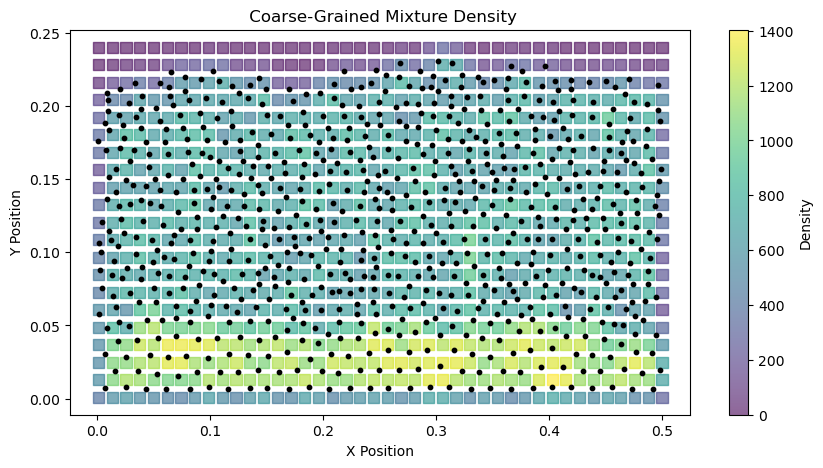

In [ ]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(111)

# Plot DEM particle positions 
bedload_DEM = pv.read('./VTU/DES_FB1_0150.vtp')
bedload_particles = bedload_DEM.points
x_particle = bedload_particles[:, 0]; y_particle = bedload_particles[:, 1]
ax.scatter(x_particle, y_particle, s=10, c='k', alpha=1, label='Particle Positions', zorder=3)

# Plot the CG data
# CG coordinates at z = 0.0
x = np.asarray(bedload_CG.positions[:, 0]) ; y = np.asarray(bedload_CG.positions[:, 1]) ; z = np.asarray(bedload_CG.positions[:, 2])
var = np.asarray(bedload_CG.density_mixture.values[0, :])
mask = np.asarray(bedload_CG.positions[:, 2]) == 0.0 # get the points that have z = 0.0
x_slice = x[mask] ; y_slice = y[mask] ; var_slice = var[mask]   
# plot the CG data
sc = ax.scatter(x_slice, y_slice, s=65, c=var_slice, 
                cmap='viridis', alpha=0.6, label='CG Density', 
                zorder=1, marker='s')

plt.colorbar(sc, ax=ax, label='Density')
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_title(' Coarse-Grained Mixture Density')
plt.show()